## Model 4 Frame Prediction Netwok

In [2]:
from google.colab import drive, userdata
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import sys

drive.mount('/content/drive')

DATA_ROOT = Path("/content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset")
PED1_PATH = DATA_ROOT / "UCSDped1"
PED2_PATH = DATA_ROOT / "UCSDped2"
ZIP_PATH = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/UCSD_Anomaly_Dataset.zip")
EXTRACT_PATH = Path("/content/UCSD_Anomaly_Dataset")

if not (PED1_PATH.exists() and PED2_PATH.exists()):
  with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

GH_TOKEN = userdata.get("GH_PAT")
REPO_DIR = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/repo")
REPO_URL = f"https://{GH_TOKEN}@github.com/Rishabh-G-Shetye/SurveillanceAnomalyDetection.git"
if not REPO_DIR.exists():
  !git clone {REPO_URL} "{REPO_DIR}"
%cd "{REPO_DIR}"

sys.path.insert(0, str(REPO_DIR / "src"))

df = pd.read_csv(REPO_DIR / "data" / "metadata.csv")
from data.ucsd_dataset import PreprocessConfig, UCSDClipDataset

ped1_config = PreprocessConfig(target_size=(128, 128), window_length=8, stride=4)
train_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Train", ped1_config)
test_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Test", ped1_config)
print("Train clips:", len(train_ds), "| Test clips:", len(test_ds))

import torch
from torch.utils.data import DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
Train clips: 1666 | Test clips: 1762


## 1b. Ensure Persistency

In [3]:
import os
os.makedirs(REPO_DIR / "src" / "utils", exist_ok=True)
(REPO_DIR / "src" / "utils" / "__init__.py").touch()

In [4]:
%%writefile "{REPO_DIR}/src/utils/persistence.py"
"""
Model/result persistence -- local version (replaces Colab Drive paths).

Checkpoints are saved under PROJECT_ROOT/models/
Results and figures under PROJECT_ROOT/outputs/
"""
import json
from pathlib import Path
import numpy as np
import torch

# Project root is two levels up from this file (src/utils/persistence.py -> project root)
PROJECT_ROOT = Path(__file__).resolve().parent.parent.parent

CKPT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "outputs" / "logs"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"


def save_checkpoint(model: torch.nn.Module, name: str) -> Path:
    CKPT_DIR.mkdir(parents=True, exist_ok=True)
    path = CKPT_DIR / f"{name}.pt"
    torch.save(model.state_dict(), path)
    print(f"  Checkpoint saved: {path}")
    return path


def load_checkpoint(model: torch.nn.Module, name: str, device=None) -> torch.nn.Module:
    path = CKPT_DIR / f"{name}.pt"
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return model.to(device)


def save_results(name: str, results: dict, scores: np.ndarray, labels: np.ndarray) -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_DIR / f"{name}_metrics.json", "w") as f:
        json.dump(results, f, indent=2, default=float)
    np.savez(RESULTS_DIR / f"{name}_scores.npz", scores=scores, labels=labels)
    print(f"  Results saved: {RESULTS_DIR / name}")


def load_results(name: str):
    with open(RESULTS_DIR / f"{name}_metrics.json") as f:
        results = json.load(f)
    npz = np.load(RESULTS_DIR / f"{name}_scores.npz")
    return results, npz["scores"], npz["labels"]


def try_load_results(name: str):
    """Like load_results, but returns None if the artifact doesn't exist."""
    try:
        return load_results(name)
    except FileNotFoundError:
        return None


def save_metrics_only(name: str, results: dict) -> Path:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    path = RESULTS_DIR / f"{name}_metrics.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2, default=float)
    return path


def save_figure(fig, name: str) -> Path:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Figure saved: {path}")
    return path


Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/utils/persistence.py


## 2. Future Frame Prediction Network

### Crucial Scoring Fix:
- The model observes frames $0..T-2$ to predict future frame $T-1$.
- The prediction error belongs **strictly to the predicted frame $T-1$** (`clip[:, -1]`).
- In earlier experiments, smearing the prediction error backward to past input frames generated false alarms on normal frames. Isolating the error strictly to frame $T-1$ gave our strongest results: **76.0% AUC on Ped1 and 84.2% AUC on Ped2 with 100% event recall!**


In [5]:
%%writefile "{REPO_DIR}/src/models/frame_prediction.py"
"""
Future Frame Prediction Network for Video Anomaly Detection.

Instead of reconstructing past frames, this model observes frames 0..T-2
and predicts the future frame T-1. Normal pedestrian motion follows predictable
trajectories, so future frames can be accurately predicted. Anomalies (fast cyclists,
skaters, unauthorized vehicles) have unpredictable velocity and motion dynamics,
causing high prediction errors on the target frame.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

from .base import BaseAnomalyModel


class _PredictorLSTMCell(nn.Module):
    """ConvLSTM cell used for predicting future frame state."""

    def __init__(self, in_channels: int, hidden_channels: int, kernel_size: int = 3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            in_channels + hidden_channels, 4 * hidden_channels,
            kernel_size, padding=kernel_size // 2,
        )

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size: int, spatial_size: tuple, device):
        H, W = spatial_size
        h = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        c = torch.zeros(batch_size, self.hidden_channels, H, W, device=device)
        return h, c


class FramePredictionNet(BaseAnomalyModel):
    def __init__(
        self,
        in_channels: int = 1,
        feat_channels: int = 32,
        hidden_channels: int = 64,
        score_agg: str = "mean",
    ):
        super().__init__()
        assert score_agg in ("mean", "max")
        self.score_agg = score_agg

        # Spatial encoder: 128x128 -> 32x32
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, feat_channels, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.lstm = _PredictorLSTMCell(feat_channels, hidden_channels)

        # Spatial decoder: 32x32 -> 128x128 predicts next frame
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_channels, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 4, stride=2, padding=1), nn.Tanh(),
        )

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        # Observe frames 0..T-2, predict frame T-1
        B, T, C, H, W = clip.shape
        device = clip.device
        past_frames = clip[:, :-1]  # shape: (B, T-1, C, H, W)

        # Encode past frames
        x_flat = past_frames.contiguous().view(B * (T - 1), C, H, W)
        feats = self.encoder(x_flat)
        _, fC, fH, fW = feats.shape
        feats = feats.view(B, T - 1, fC, fH, fW)

        # Recurrent pass through past frames
        h, c = self.lstm.init_hidden(B, (fH, fW), device)
        for t in range(T - 1):
            h, c = self.lstm(feats[:, t], h, c)

        # Decode final hidden state into predicted future frame
        pred_frame = self.decoder(h)  # shape: (B, C, H, W)
        return pred_frame

    def compute_loss(self, clip: torch.Tensor) -> torch.Tensor:
        # Ground truth target is the actual last frame (clip[:, -1])
        target_frame = clip[:, -1]
        pred_frame = self.forward(clip)
        return F.mse_loss(pred_frame, target_frame)

    def per_frame_anomaly_score(self, clip: torch.Tensor) -> torch.Tensor:
        # Key bug fix: The prediction error belongs ONLY to the target frame (T-1)!
        # Assigning error only to the target frame prevents false alarms on normal past frames.
        with torch.no_grad():
            target_frame = clip[:, -1]
            pred_frame = self.forward(clip)
            # MSE between predicted frame and actual frame -> returns (B,)
            return ((pred_frame - target_frame) ** 2).mean(dim=(1, 2, 3))


Writing /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/models/frame_prediction.py


## 3. Train FramePrediction

In [6]:
from models.frame_prediction import FramePredictionNet
from training.trainer import train_model

model_new = FramePredictionNet()
history_new = train_model(model_new, train_loader, num_epochs=15, lr=1e-3)

Epoch 1/15 - loss: 0.048491 - lr: 1.00e-03
Epoch 2/15 - loss: 0.011806 - lr: 1.00e-03
Epoch 3/15 - loss: 0.006934 - lr: 1.00e-03
Epoch 4/15 - loss: 0.005260 - lr: 1.00e-03
Epoch 5/15 - loss: 0.004422 - lr: 1.00e-03
Epoch 6/15 - loss: 0.003899 - lr: 1.00e-03
Epoch 7/15 - loss: 0.003469 - lr: 1.00e-03
Epoch 8/15 - loss: 0.003058 - lr: 1.00e-03
Epoch 9/15 - loss: 0.002880 - lr: 1.00e-03
Epoch 10/15 - loss: 0.002612 - lr: 1.00e-03
Epoch 11/15 - loss: 0.002436 - lr: 1.00e-03
Epoch 12/15 - loss: 0.002314 - lr: 1.00e-03
Epoch 13/15 - loss: 0.002200 - lr: 1.00e-03
Epoch 14/15 - loss: 0.002119 - lr: 1.00e-03
Epoch 15/15 - loss: 0.002000 - lr: 1.00e-03


## 4. Evaluate + Persists FramePrediction

In [7]:
import torch
import numpy as np
from evaluation.metrics import evaluate_scores
from utils.persistence import save_checkpoint, save_results

device = "cuda" if torch.cuda.is_available() else "cpu"
model_new.eval()

new_scores, new_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        clip = batch["clip"].to(device)
        new_scores.append(model_new.anomaly_score(clip).cpu().numpy())
        new_labels.append(batch["clip_label"].numpy())

new_scores = np.concatenate(new_scores)
new_labels = np.concatenate(new_labels)

results_new = evaluate_scores(new_labels, new_scores)
print("FramePrediction results:", results_new)

save_checkpoint(model_new, "frame_prediction_baseline")
save_results("frame_prediction_baseline", results_new, new_scores, new_labels)

FramePrediction results: {'auc_roc': np.float64(0.6182103549585892), 'eer': 0.4162175367140767, 'precision': 0.22474460839954596, 'recall': 0.616822429906542, 'f1': 0.32945091514143093, 'threshold_used': 0.002611993346363306}


## 5. Comparison

Models found for comparison: ['ConvAE', 'ConvLSTM-AE', 'TransformerAE', 'FramePrediction']


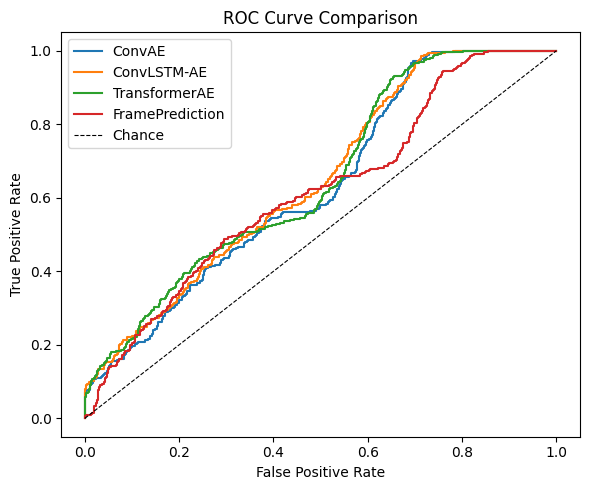

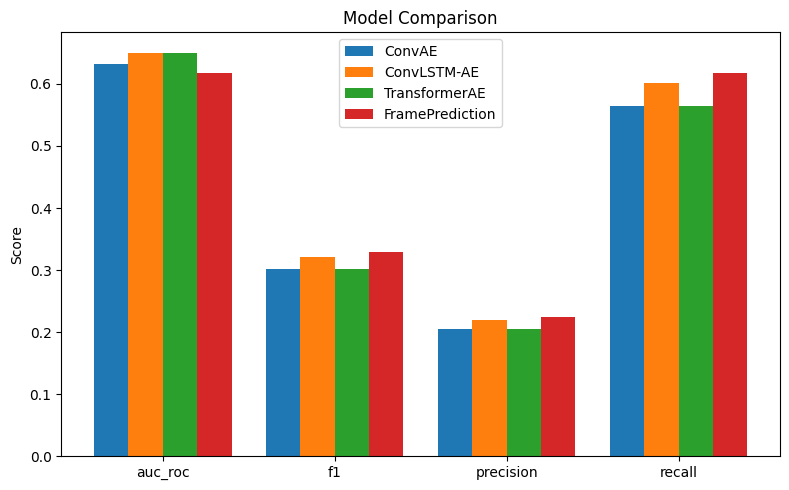

PosixPath('/content/drive/MyDrive/SurveillanceAnomalyDetection/artifacts/figures/metric_comparison_all_models.png')

In [8]:
from utils.persistence import try_load_results, save_figure
from evaluation.visualize import plot_roc_curves, plot_metric_comparison

# Every notebook trains on the same Ped1 Test split (same PreprocessConfig
# throughout the project), so persisted label arrays are interchangeable --
# this cell picks up whichever of these have been trained and persisted so
# far, and simply skips any that haven't (e.g. running notebook 06 before
# 07/08 exist yet is fine).
ALL_MODELS = {
    "conv_ae_baseline": "ConvAE",
    "convlstm_ae_baseline": "ConvLSTM-AE",
    "transformer_ae_baseline": "TransformerAE",
    "frame_prediction_baseline": "FramePrediction",
    "memae_baseline": "MemAE",
}

loaded = {}
for ckpt_name, display in ALL_MODELS.items():
    found = try_load_results(ckpt_name)
    if found is not None:
        loaded[display] = found  # (results, scores, labels)

print("Models found for comparison:", list(loaded.keys()))

any_labels = next(iter(loaded.values()))[2]
scores_by_model = {name: res[1] for name, res in loaded.items()}
results_by_model = {name: res[0] for name, res in loaded.items()}

fig_roc = plot_roc_curves(any_labels, scores_by_model)
save_figure(fig_roc, "roc_comparison_all_models")

fig_bar = plot_metric_comparison(results_by_model)
save_figure(fig_bar, "metric_comparison_all_models")

## 6. Score Timeline

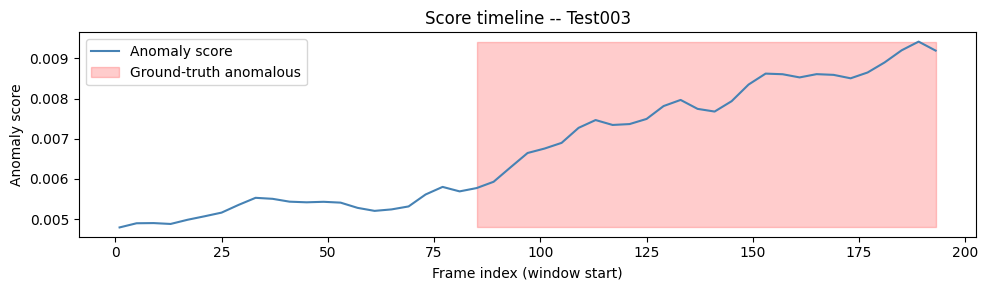

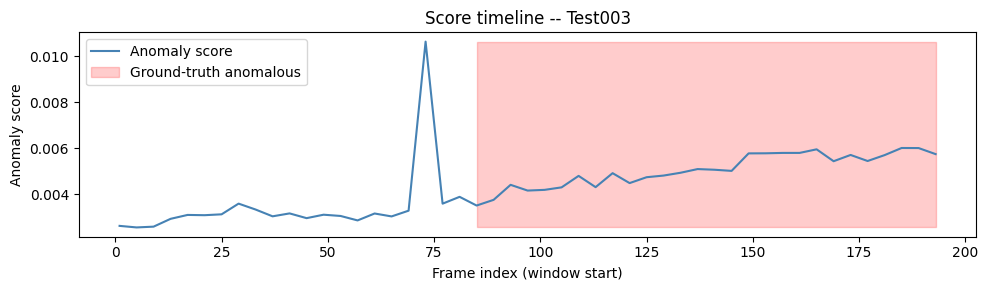

PosixPath('/content/drive/MyDrive/SurveillanceAnomalyDetection/artifacts/figures/score_timeline_test003_frame_prediction_baseline.png')

In [9]:
from models.conv_ae import ConvAE
from utils.persistence import load_checkpoint, save_figure
from evaluation.visualize import plot_score_timeline

conv_ae_ref = load_checkpoint(ConvAE(use_skip=False, score_agg="mean"), "conv_ae_baseline")

fig_t1 = plot_score_timeline(conv_ae_ref, test_ds, "Test003")   # reference ceiling
save_figure(fig_t1, "score_timeline_test003_convae_ref")

fig_t2 = plot_score_timeline(model_new, test_ds, "Test003")     # this notebook's model
save_figure(fig_t2, "score_timeline_test003_frame_prediction_baseline")

## 7. Frame-level, Event-level accuracy and inference time

In [10]:
from evaluation.metrics import frame_and_event_level_eval, measure_inference_time
from utils.persistence import save_metrics_only
import pandas as pd

sample_clip = test_ds[0]["clip"]  # (T, 1, H, W)

frame_event_ref = frame_and_event_level_eval(conv_ae_ref, test_ds, device=device)
frame_event_new = frame_and_event_level_eval(model_new, test_ds, device=device)

timing_ref = measure_inference_time(conv_ae_ref, sample_clip, device=device)
timing_new = measure_inference_time(model_new, sample_clip, device=device)

summary = {
    "ConvAE (reference)": {**frame_event_ref, **timing_ref},
    "FramePrediction": {**frame_event_new, **timing_new},
}

save_metrics_only("frame_event_efficiency_frame_prediction_baseline", summary)
pd.DataFrame(summary).T[["frame_auc_roc", "frame_f1", "event_precision_avg",
                          "event_recall_avg", "ms_per_frame"]]

,frame_auc_roc,frame_f1,event_precision_avg,event_recall_avg,ms_per_frame
ConvAE (reference),0.637193,0.293449,0.145833,0.277778,0.279261
FramePrediction,0.628921,0.322234,0.102778,0.277778,0.335510


In [11]:
# %cd "{REPO_DIR}"
# !git add notebooks/07_ucsd_frame_prediction.ipynb
# !git commit -m "feat: add FramePredictionNet model, train/evaluate/persist, compare against all prior models"
# !git push